Processing Surface
  -> using cos(lat)
Processing 100 m
  -> using cos(lat)
Processing 200 m
  -> using cos(lat)
Processing 300 m
  -> using cos(lat)
Processing 400 m
  -> using cos(lat)
Processing 500 m
  -> using cos(lat)
Finished computing global mean O2 saturation.
----------------------------------------------------------------------
Surface
  Min O2 saturation: 99.585 %
  Max O2 saturation: 101.295 %
  First below 60%: None
  First below 5% : None
100 m
  Min O2 saturation: 86.993 %
  Max O2 saturation: 90.041 %
  First below 60%: None
  First below 5% : None
200 m
  Min O2 saturation: 70.330 %
  Max O2 saturation: 72.348 %
  First below 60%: None
  First below 5% : None
300 m
  Min O2 saturation: 62.444 %
  Max O2 saturation: 64.218 %
  First below 60%: None
  First below 5% : None
400 m
  Min O2 saturation: 58.040 %
  Max O2 saturation: 60.556 %
  First below 60%: 1850-01-16 12:00:00
  First below 5% : None
500 m
  Min O2 saturation: 54.342 %
  Max O2 saturation: 57.647 %
  Fir

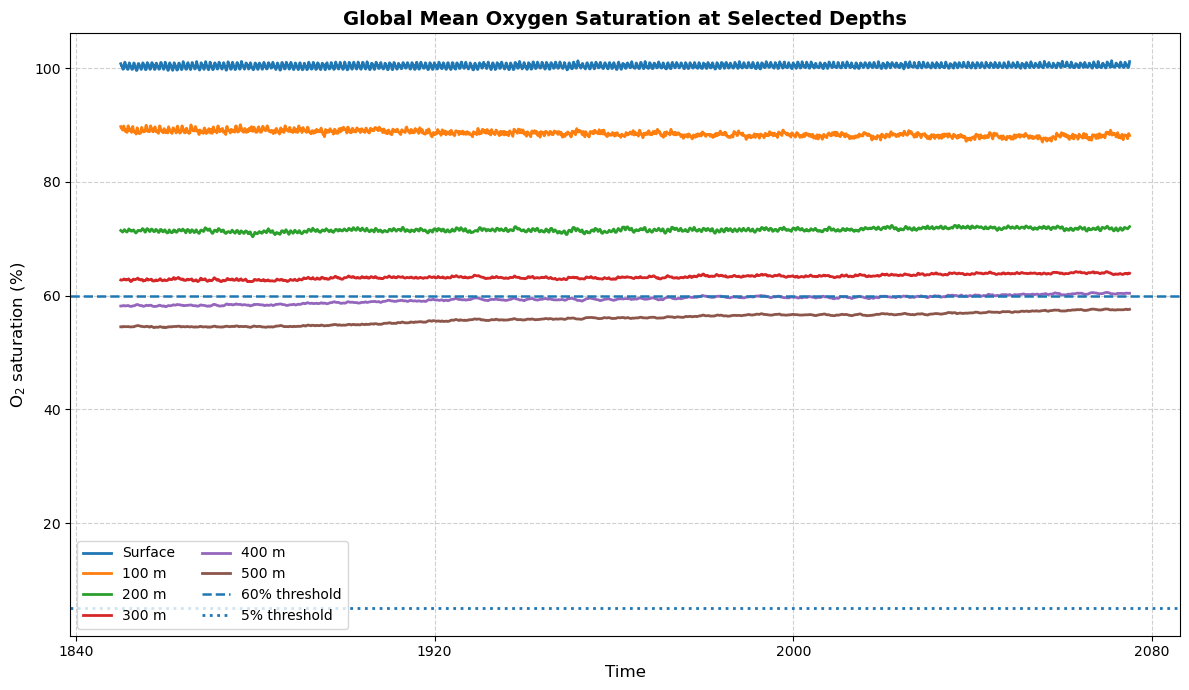

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

DEPTH_FILES = {
    "Surface": {
        "o2":    f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "o2sat": f"{BASE_DIR}/surface_1x1_o2sat/o2sat_sfc_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "100 m": {
        "o2":    f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "o2sat": f"{BASE_DIR}/depth_100m_1x1_o2sat/o2sat_100m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "200 m": {
        "o2":    f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "o2sat": f"{BASE_DIR}/depth_200m_1x1_o2sat/o2sat_200m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "300 m": {
        "o2":    f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "o2sat": f"{BASE_DIR}/depth_300m_1x1_o2sat/o2sat_300m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "400 m": {
        "o2":    f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "o2sat": f"{BASE_DIR}/depth_400m_1x1_o2sat/o2sat_400m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "500 m": {
        "o2":    f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "o2sat": f"{BASE_DIR}/depth_500m_1x1_o2sat/o2sat_500m_1x1_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
}

THRESHOLD_SHALLOW = 60.0  # %
THRESHOLD_DEEP = 5.0      # %

# ============================================================
# Function
# ============================================================

def open_var(file_pattern, varname):
    files = sorted(glob.glob(file_pattern))
    if len(files) == 0:
        raise FileNotFoundError(f"No files found for {varname}: {file_pattern}")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    da = ds[varname]

    if "lev" in da.dims:
        da = da.isel(lev=0, drop=True)

    return ds, da


def compute_global_mean_o2_saturation(pattern_o2, pattern_o2sat, label):
    print(f"Processing {label}")

    ds_o2, o2 = open_var(pattern_o2, "o2")
    ds_sat, o2sat = open_var(pattern_o2sat, "o2sat")

    # Align time/coords just in case
    o2, o2sat = xr.align(o2, o2sat, join="inner")

    # O2 saturation in %
    o2sat_percent = (o2 / o2sat) * 100.0
    o2sat_percent.attrs["units"] = "%"
    o2sat_percent.attrs["long_name"] = "Oxygen saturation"

    horizontal_dims = [dim for dim in o2sat_percent.dims if dim != "time"]

    # Area weights
    if ("lat" in ds_o2.coords) and ("lon" in ds_o2.coords):
        weights = np.cos(np.deg2rad(ds_o2["lat"]))
        print("  -> using cos(lat)")
    elif "latitude" in ds_o2:
        lat = ds_o2["latitude"].where(np.abs(ds_o2["latitude"]) <= 90)
        weights = np.cos(np.deg2rad(lat))
        print("  -> using cos(latitude)")
    else:
        raise ValueError(f"No latitude information found for {label}")

    ocean_mask = o2sat_percent.isel(time=0).notnull()
    weights = weights.where(ocean_mask).fillna(0)

    gm = o2sat_percent.weighted(weights).mean(
        dim=horizontal_dims,
        skipna=True
    ).compute()

    gm.name = label

    ds_o2.close()
    ds_sat.close()

    return gm


# ============================================================
# Compute all depth means
# ============================================================

global_means = {}

for label, paths in DEPTH_FILES.items():
    gm = compute_global_mean_o2_saturation(
        paths["o2"],
        paths["o2sat"],
        label
    )
    global_means[label] = gm

print("Finished computing global mean O2 saturation.")


# ============================================================
# Summary
# ============================================================

def find_first_below_time(da, threshold):
    mask = da < threshold
    if bool(mask.any().values):
        return da["time"].where(mask, drop=True).isel(time=0).values
    return None


print("-" * 70)

for label, da in global_means.items():
    print(f"{label}")
    print(f"  Min O2 saturation: {float(da.min().values):.3f} %")
    print(f"  Max O2 saturation: {float(da.max().values):.3f} %")
    print(f"  First below 60%: {find_first_below_time(da, THRESHOLD_SHALLOW)}")
    print(f"  First below 5% : {find_first_below_time(da, THRESHOLD_DEEP)}")

print("-" * 70)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(12, 7))

for label, da in global_means.items():
    da.plot(linewidth=2, label=label)

plt.axhline(
    THRESHOLD_SHALLOW,
    linestyle="--",
    linewidth=1.8,
    label="60% threshold"
)

plt.axhline(
    THRESHOLD_DEEP,
    linestyle=":",
    linewidth=2.0,
    label="5% threshold"
)

plt.title(
    "Global Mean Oxygen Saturation at Selected Depths",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time", fontsize=12)
plt.ylabel("O$_2$ saturation (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(ncol=2)
plt.tight_layout()

plt.savefig("global_mean_o2_saturation_selected_depths.png", dpi=300)
plt.show()

In [3]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

DEPTH_FILES = {
    "Surface": {
        "o2":    f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/surface_1x1_o2sat/o2sat_sfc_1x1_Omon_*.nc",
    },
    "100 m": {
        "o2":    f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_100m_1x1_o2sat/o2sat_100m_1x1_Omon_*.nc",
    },
    "200 m": {
        "o2":    f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_200m_1x1_o2sat/o2sat_200m_1x1_Omon_*.nc",
    },
    "300 m": {
        "o2":    f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_300m_1x1_o2sat/o2sat_300m_1x1_Omon_*.nc",
    },
    "400 m": {
        "o2":    f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_400m_1x1_o2sat/o2sat_400m_1x1_Omon_*.nc",
    },
    "500 m": {
        "o2":    f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_500m_1x1_o2sat/o2sat_500m_1x1_Omon_*.nc",
    },
}

THRESHOLD = 60.0
MIN_MONTHS = 12

# ============================================================
# Critical year function
# ============================================================

def first_persistent_below_year(values, years,
                                threshold=60.0,
                                min_months=12):

    below = np.isfinite(values) & (values < threshold)

    count = 0

    for k, flag in enumerate(below):

        if flag:
            count += 1
        else:
            count = 0

        if count >= min_months:
            start_idx = k - min_months + 1
            return float(years[start_idx])

    return np.nan


# ============================================================
# Compute maps
# ============================================================

critical_maps = {}

for depth_label, paths in DEPTH_FILES.items():

    print(f"Processing {depth_label}")

    ds_o2 = xr.open_mfdataset(
        sorted(glob.glob(paths["o2"])),
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    ds_sat = xr.open_mfdataset(
        sorted(glob.glob(paths["o2sat"])),
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    o2 = ds_o2["o2"]
    o2sat = ds_sat["o2sat"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    if "lev" in o2sat.dims:
        o2sat = o2sat.isel(lev=0, drop=True)

    o2, o2sat = xr.align(o2, o2sat)

    saturation = (o2 / o2sat) * 100.0

    years = saturation.time.dt.year.astype(np.int32)

    critical_year = xr.apply_ufunc(
        first_persistent_below_year,
        saturation,
        years,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        kwargs={
            "threshold": THRESHOLD,
            "min_months": MIN_MONTHS,
        },
    )

    print("  Computing...")
    critical_maps[depth_label] = critical_year.compute()

    ds_o2.close()
    ds_sat.close()

print("Done.")

Processing Surface
  Computing...
Processing 100 m
  Computing...
Processing 200 m
  Computing...
Processing 300 m
  Computing...
Processing 400 m
  Computing...
Processing 500 m
  Computing...
Done.


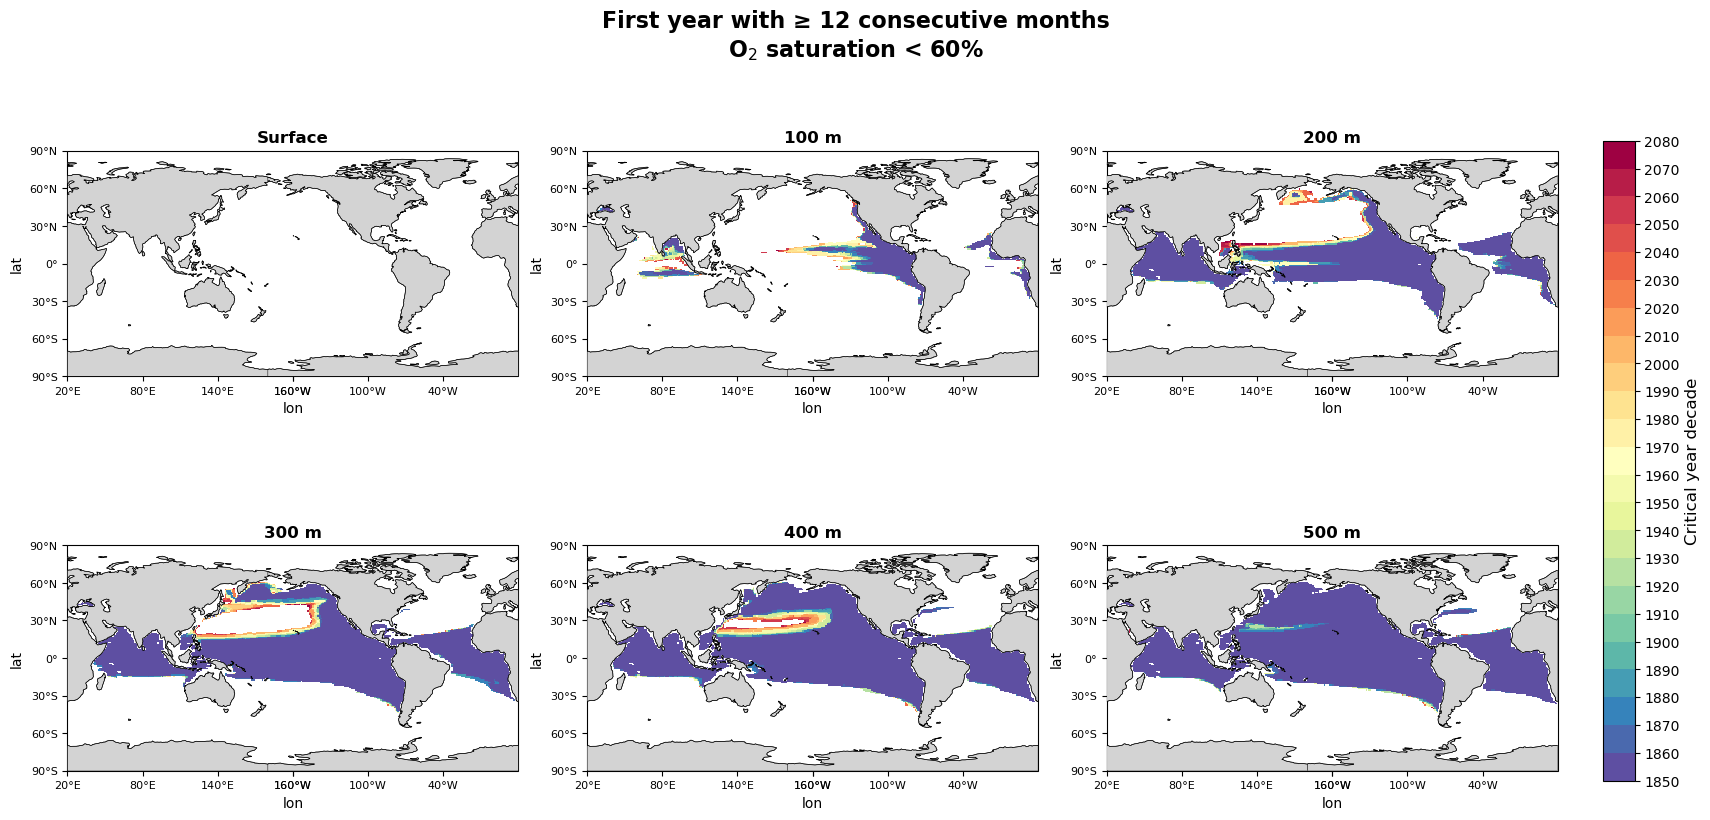

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import warnings

warnings.filterwarnings("ignore",
                        message="The colormap's 'bad' has been set")

# ============================================================
# Colorbar
# ============================================================

all_values = np.concatenate([
    da.values[np.isfinite(da.values)]
    for da in critical_maps.values()
])

start_decade = int(np.floor(np.nanmin(all_values) / 10) * 10)
end_decade = int(np.ceil(np.nanmax(all_values) / 10) * 10)

bounds = np.arange(start_decade, end_decade + 10, 10)

cmap = plt.get_cmap("Spectral_r",
                    len(bounds) - 1).copy()

cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 8.5),
    subplot_kw={"projection": map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (depth_label, critical_year) in zip(
        axes,
        critical_maps.items()):

    pcm = critical_year.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11
    )

    ax.set_global()

    ax.set_xticks(
        np.arange(-160, 201, 60),
        crs=data_crs
    )

    ax.set_yticks(
        np.arange(-90, 91, 30),
        crs=data_crs
    )

    ax.xaxis.set_major_formatter(
        cticker.LongitudeFormatter()
    )

    ax.yaxis.set_major_formatter(
        cticker.LatitudeFormatter()
    )

    ax.tick_params(labelsize=8)

    ax.set_title(
        depth_label,
        fontsize=12,
        fontweight="bold"
    )

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=bounds,
    ticks=bounds,
    spacing="proportional",
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Critical year decade",
    fontsize=12
)

fig.suptitle(
    f"First year with ≥ {MIN_MONTHS} consecutive months\n"
    f"O$_2$ saturation < {THRESHOLD:.0f}%",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    f"critical_year_O2saturation_{THRESHOLD:.0f}pct_"
    f"{MIN_MONTHS}months_depth_panels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

DEPTH_FILES = {
    "Surface": {
        "o2":    f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/surface_1x1_o2sat/o2sat_sfc_1x1_Omon_*.nc",
    },
    "100 m": {
        "o2":    f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_100m_1x1_o2sat/o2sat_100m_1x1_Omon_*.nc",
    },
    "200 m": {
        "o2":    f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_200m_1x1_o2sat/o2sat_200m_1x1_Omon_*.nc",
    },
    "300 m": {
        "o2":    f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_300m_1x1_o2sat/o2sat_300m_1x1_Omon_*.nc",
    },
    "400 m": {
        "o2":    f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_400m_1x1_o2sat/o2sat_400m_1x1_Omon_*.nc",
    },
    "500 m": {
        "o2":    f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_500m_1x1_o2sat/o2sat_500m_1x1_Omon_*.nc",
    },
}

# ============================================================
# Trend function
# ============================================================

def linear_trend_1d(values, years):
    """
    Linear trend of values against decimal years.
    Return trend per century.
    """
    valid = np.isfinite(values) & np.isfinite(years)

    if valid.sum() < 24:
        return np.nan

    x = years[valid]
    y = values[valid]

    slope = np.polyfit(x, y, 1)[0]

    return slope * 100.0  # per century


# ============================================================
# Compute trend maps
# ============================================================

trend_maps = {}

for depth_label, paths in DEPTH_FILES.items():

    print(f"Processing {depth_label}")

    ds_o2 = xr.open_mfdataset(
        sorted(glob.glob(paths["o2"])),
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    ds_sat = xr.open_mfdataset(
        sorted(glob.glob(paths["o2sat"])),
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1}
    )

    o2 = ds_o2["o2"]
    o2sat = ds_sat["o2sat"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    if "lev" in o2sat.dims:
        o2sat = o2sat.isel(lev=0, drop=True)

    o2, o2sat = xr.align(o2, o2sat)

    saturation = (o2 / o2sat) * 100.0
    saturation.name = "o2_saturation"

    # decimal year: year + (month - 0.5) / 12
    decimal_year = (
        saturation.time.dt.year
        + (saturation.time.dt.month - 0.5) / 12.0
    ).astype(float)

    trend = xr.apply_ufunc(
        linear_trend_1d,
        saturation,
        decimal_year,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
    )

    print("  Computing trend...")
    trend_maps[depth_label] = trend.compute()

    ds_o2.close()
    ds_sat.close()

print("Done.")

Processing Surface
  Computing trend...
Processing 100 m
  Computing trend...
Processing 200 m
  Computing trend...
Processing 300 m
  Computing trend...
Processing 400 m
  Computing trend...
Processing 500 m
  Computing trend...
Done.


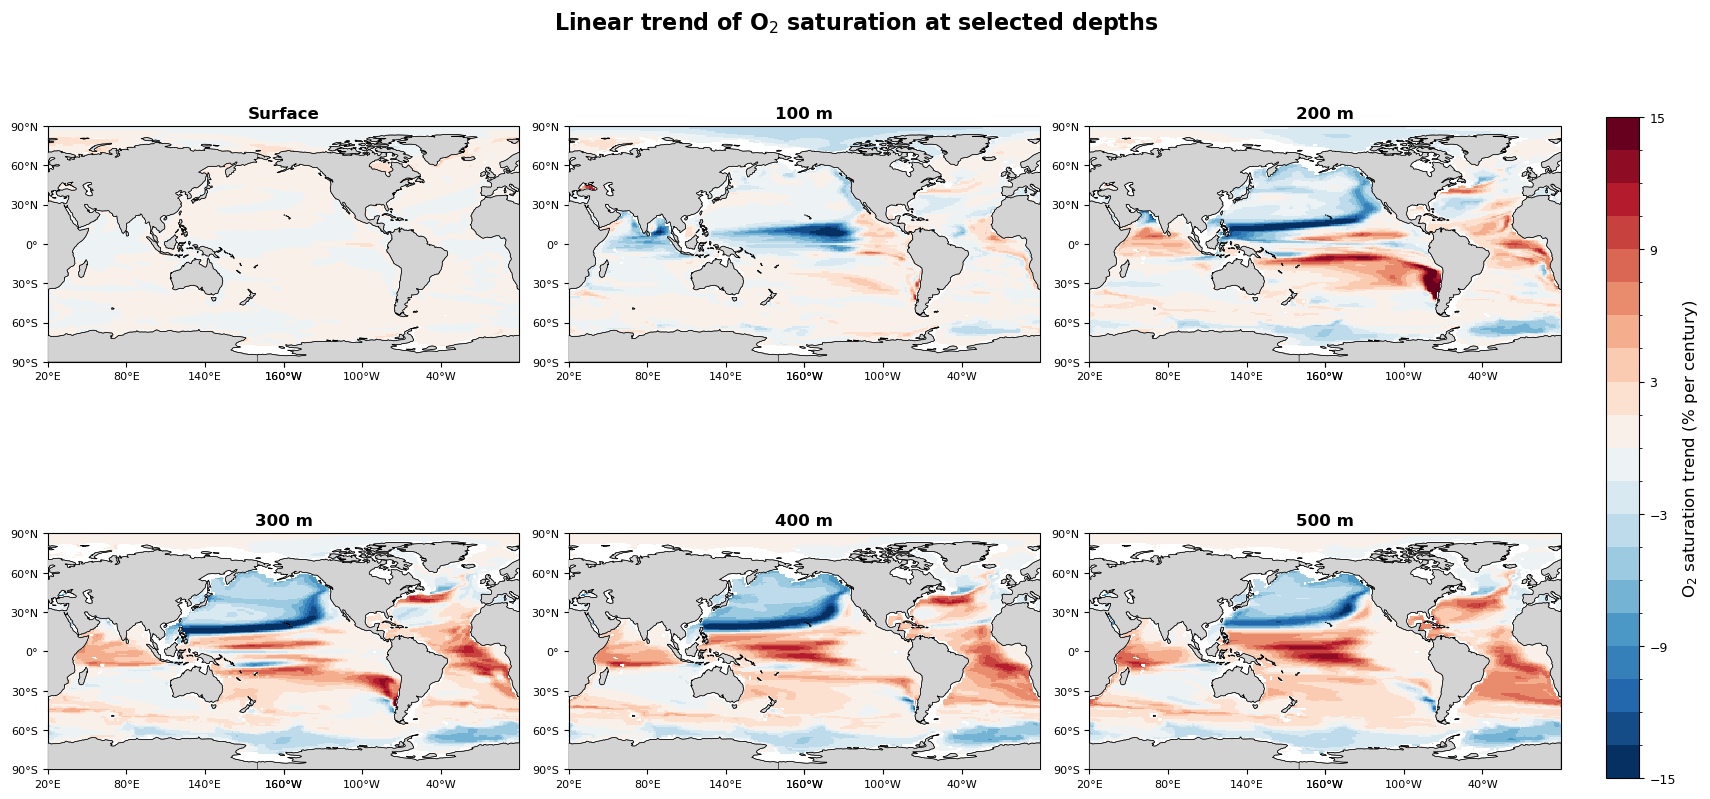

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Symmetric color range around zero
# ============================================================

all_values = np.concatenate([
    da.values[np.isfinite(da.values)]
    for da in trend_maps.values()
])

vmax = np.nanpercentile(np.abs(all_values), 98)
vmin = -vmax

# Optional: round color range
vmax = np.ceil(vmax / 5) * 5
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 8.5),
    subplot_kw={"projection": map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (depth_label, trend) in zip(axes, trend_maps.items()):

    pcm = trend.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11
    )

    ax.set_global()

    ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        depth_label,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "O$_2$ saturation trend (% per century)",
    fontsize=12
)

cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Linear trend of O$_2$ saturation at selected depths",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "trend_O2saturation_percent_per_century_depth_panels_center200E.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Computing CO2...
Computing O2 saturation...
Surface
100 m
200 m
300 m
400 m
500 m


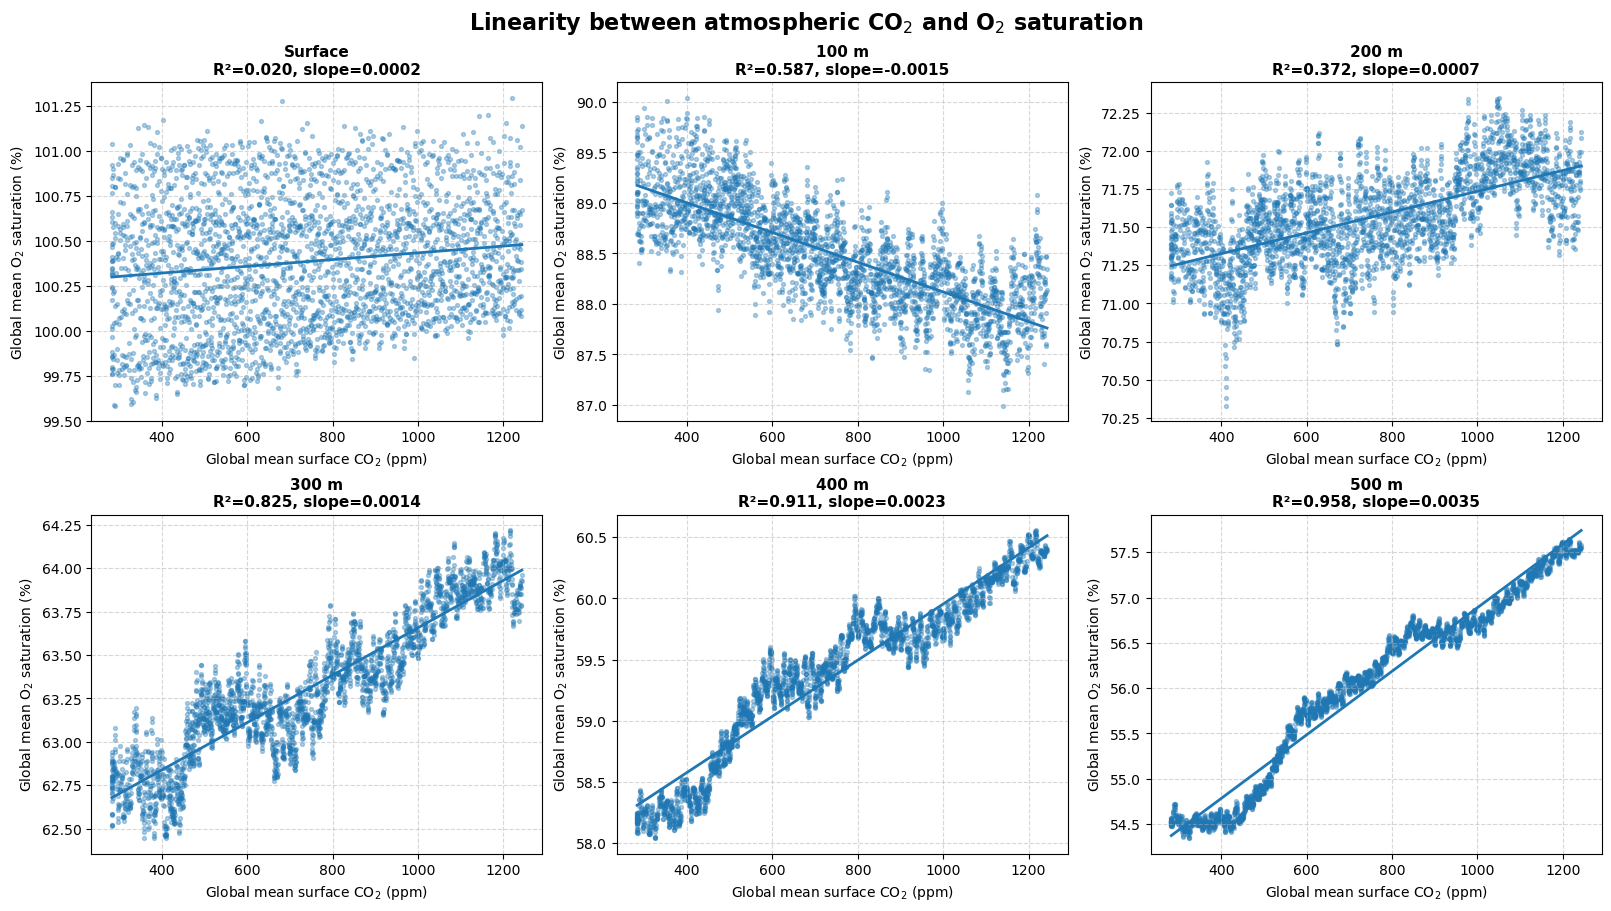

------------------------------------------------------------------------------------------
O2 saturation (%) = slope × CO2(ppm) + intercept
------------------------------------------------------------------------------------------
Surface  | n= 2700 | slope=0.000187 % ppm-1 | R2=0.0203
100 m    | n= 2700 | slope=-0.001470 % ppm-1 | R2=0.5868
200 m    | n= 2700 | slope=0.000682 % ppm-1 | R2=0.3715
300 m    | n= 2700 | slope=0.001366 % ppm-1 | R2=0.8251
400 m    | n= 2700 | slope=0.002294 % ppm-1 | R2=0.9114
500 m    | n= 2700 | slope=0.003507 % ppm-1 | R2=0.9578


In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

DEPTH_FILES = {
    "Surface": {
        "o2":    f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/surface_1x1_o2sat/o2sat_sfc_1x1_Omon_*.nc",
    },
    "100 m": {
        "o2":    f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_100m_1x1_o2sat/o2sat_100m_1x1_Omon_*.nc",
    },
    "200 m": {
        "o2":    f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_200m_1x1_o2sat/o2sat_200m_1x1_Omon_*.nc",
    },
    "300 m": {
        "o2":    f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_300m_1x1_o2sat/o2sat_300m_1x1_Omon_*.nc",
    },
    "400 m": {
        "o2":    f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_400m_1x1_o2sat/o2sat_400m_1x1_Omon_*.nc",
    },
    "500 m": {
        "o2":    f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_500m_1x1_o2sat/o2sat_500m_1x1_Omon_*.nc",
    },
}

# ============================================================
# CO2 global mean
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):

    files = sorted(glob.glob(file_pattern))

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"]))

    co2_gm = co2.weighted(weights).mean(
        dim=["lat", "lon"],
        skipna=True
    )

    co2_ppm = (co2_gm * 1e6).compute()

    ds.close()

    return co2_ppm


# ============================================================
# O2 saturation global mean
# ============================================================

def compute_global_mean_o2sat(pattern_o2,
                              pattern_o2sat,
                              label):

    files_o2 = sorted(glob.glob(pattern_o2))
    files_sat = sorted(glob.glob(pattern_o2sat))

    print(f"{label}")

    ds_o2 = xr.open_mfdataset(
        files_o2,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    ds_sat = xr.open_mfdataset(
        files_sat,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    o2 = ds_o2["o2"]
    o2sat = ds_sat["o2sat"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0, drop=True)

    if "lev" in o2sat.dims:
        o2sat = o2sat.isel(lev=0, drop=True)

    o2, o2sat = xr.align(o2, o2sat)

    saturation = (o2 / o2sat) * 100.0

    if ("lat" in ds_o2.coords) and ("lon" in ds_o2.coords):
        weights = np.cos(np.deg2rad(ds_o2["lat"]))
        spatial_dims = ["lat", "lon"]
    else:
        lat = ds_o2["latitude"].where(
            np.abs(ds_o2["latitude"]) <= 90
        )
        weights = np.cos(np.deg2rad(lat))
        spatial_dims = ["j", "i"]

    ocean_mask = saturation.isel(time=0).notnull()

    weights = weights.where(ocean_mask).fillna(0)

    sat_gm = saturation.weighted(weights).mean(
        dim=spatial_dims,
        skipna=True
    ).compute()

    ds_o2.close()
    ds_sat.close()

    return sat_gm


# ============================================================
# Compute series
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

print("Computing O2 saturation...")

sat_series = {}

for label, paths in DEPTH_FILES.items():

    sat_series[label] = compute_global_mean_o2sat(
        paths["o2"],
        paths["o2sat"],
        label
    )

# ============================================================
# Regression
# ============================================================

fit_results = {}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (label, sat_da) in zip(
        axes,
        sat_series.items()):

    co2_aligned, sat_aligned = xr.align(
        co2_ppm,
        sat_da,
        join="inner"
    )

    x = co2_aligned.values
    y = sat_aligned.values

    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    reg = linregress(x, y)

    y_fit = reg.slope * x + reg.intercept
    r2 = reg.rvalue ** 2

    fit_results[label] = {
        "slope": reg.slope,
        "intercept": reg.intercept,
        "r2": r2,
        "n": len(x),
    }

    idx = np.argsort(x)

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.35
    )

    ax.plot(
        x[idx],
        y_fit[idx],
        linewidth=2
    )

    ax.set_title(
        f"{label}\n"
        f"R²={r2:.3f}, "
        f"slope={reg.slope:.4f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Global mean surface CO$_2$ (ppm)"
    )

    ax.set_ylabel(
        "Global mean O$_2$ saturation (%)"
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

fig.suptitle(
    "Linearity between atmospheric CO$_2$ and O$_2$ saturation",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "linear_relationship_CO2_vs_O2saturation.png",
    dpi=300
)

plt.show()

# ============================================================
# Summary
# ============================================================

print("-" * 90)
print("O2 saturation (%) = slope × CO2(ppm) + intercept")
print("-" * 90)

for label, res in fit_results.items():

    print(
        f"{label:8s} | "
        f"n={res['n']:5d} | "
        f"slope={res['slope']:.6f} % ppm-1 | "
        f"R2={res['r2']:.4f}"
    )

In [8]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

DEPTH_FILES = {
    "Surface": {
        "o2":    f"{BASE_DIR}/surface_1x1/o2_sfc_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/surface_1x1_o2sat/o2sat_sfc_1x1_Omon_*.nc",
    },
    "100 m": {
        "o2":    f"{BASE_DIR}/depth_100m_1x1/o2_100m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_100m_1x1_o2sat/o2sat_100m_1x1_Omon_*.nc",
    },
    "200 m": {
        "o2":    f"{BASE_DIR}/depth_200m_1x1/o2_200m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_200m_1x1_o2sat/o2sat_200m_1x1_Omon_*.nc",
    },
    "300 m": {
        "o2":    f"{BASE_DIR}/depth_300m_1x1/o2_300m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_300m_1x1_o2sat/o2sat_300m_1x1_Omon_*.nc",
    },
    "400 m": {
        "o2":    f"{BASE_DIR}/depth_400m_1x1/o2_400m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_400m_1x1_o2sat/o2sat_400m_1x1_Omon_*.nc",
    },
    "500 m": {
        "o2":    f"{BASE_DIR}/depth_500m_1x1/o2_500m_1x1_Omon_*.nc",
        "o2sat": f"{BASE_DIR}/depth_500m_1x1_o2sat/o2sat_500m_1x1_Omon_*.nc",
    },
}

# ============================================================
# CO2
# ============================================================

files = sorted(glob.glob(CO2_PATTERN))

ds_co2 = xr.open_mfdataset(
    files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override"
)

co2 = ds_co2["co2"]

if "plev" in co2.dims:
    co2 = co2.isel(plev=-1)

weights = np.cos(np.deg2rad(ds_co2.lat))

co2_ppm = (
    co2.weighted(weights)
       .mean(("lat","lon"))
       * 1e6
).compute()

# ============================================================
# R² function
# ============================================================

def r2_1d(x, y):

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 24:
        return np.nan

    xx = x[valid]
    yy = y[valid]

    if np.nanstd(yy) == 0:
        return np.nan

    r = np.corrcoef(xx, yy)[0,1]

    return r**2

# ============================================================
# Compute maps
# ============================================================

r2_maps = {}

for depth_label, paths in DEPTH_FILES.items():

    print(depth_label)

    ds_o2 = xr.open_mfdataset(
        sorted(glob.glob(paths["o2"])),
        combine="by_coords",
        use_cftime=True,
        chunks={"time": -1}
    )

    ds_sat = xr.open_mfdataset(
        sorted(glob.glob(paths["o2sat"])),
        combine="by_coords",
        use_cftime=True,
        chunks={"time": -1}
    )

    o2 = ds_o2["o2"]
    o2sat = ds_sat["o2sat"]

    if "lev" in o2.dims:
        o2 = o2.isel(lev=0)

    if "lev" in o2sat.dims:
        o2sat = o2sat.isel(lev=0)

    saturation = (o2 / o2sat) * 100.

    co2_aligned, sat_aligned = xr.align(
        co2_ppm,
        saturation,
        join="inner"
    )

    r2_map = xr.apply_ufunc(
        r2_1d,
        co2_aligned,
        sat_aligned,
        input_core_dims=[["time"],["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk":True},
        output_dtypes=[float]
    )

    r2_maps[depth_label] = r2_map.compute()

    ds_o2.close()
    ds_sat.close()

print("Done.")

Surface
100 m
200 m
300 m
400 m
500 m
Done.


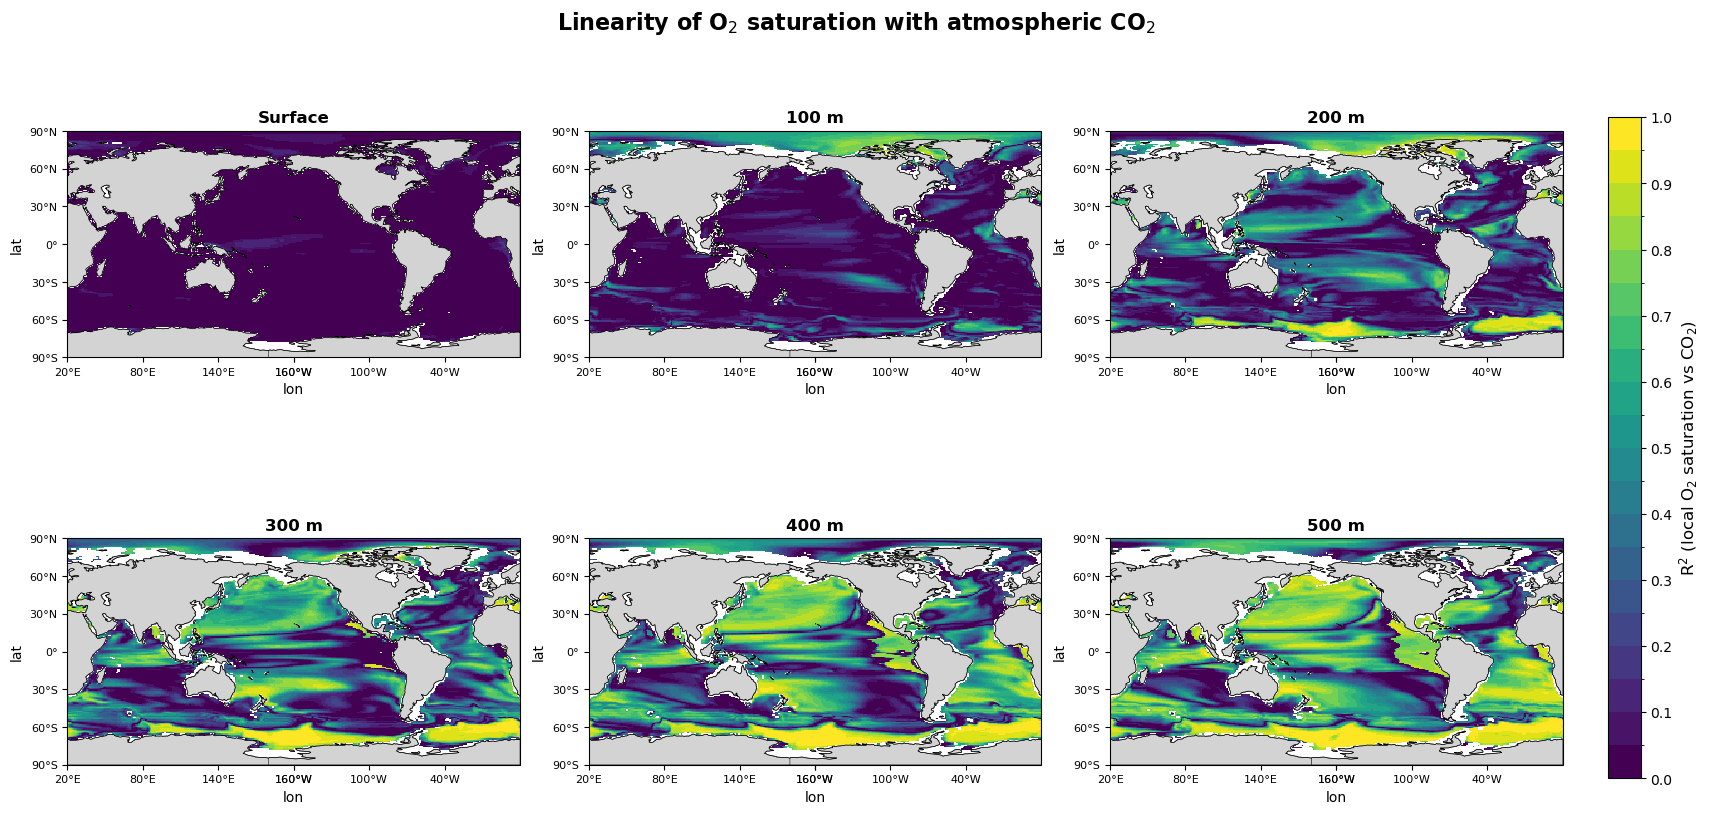

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

# ============================================================
# Colorbar
# ============================================================

levels = np.arange(0, 1.05, 0.05)

cmap = plt.get_cmap("viridis", len(levels)-1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17,8.5),
    subplot_kw={"projection":map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (depth_label, r2_map) in zip(
        axes,
        r2_maps.items()):

    pcm = r2_map.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5
    )

    ax.set_global()

    ax.set_xticks(
        np.arange(-160,201,60),
        crs=data_crs
    )

    ax.set_yticks(
        np.arange(-90,91,30),
        crs=data_crs
    )

    ax.xaxis.set_major_formatter(
        cticker.LongitudeFormatter()
    )

    ax.yaxis.set_major_formatter(
        cticker.LatitudeFormatter()
    )

    ax.tick_params(labelsize=8)

    ax.set_title(
        depth_label,
        fontsize=12,
        fontweight="bold"
    )

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=levels,
    ticks=np.arange(0,1.1,0.1),
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "R$^2$ (local O$_2$ saturation vs CO$_2$)",
    fontsize=12
)

fig.suptitle(
    "Linearity of O$_2$ saturation with atmospheric CO$_2$",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "R2_O2saturation_vs_CO2_depth_panels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()